Total samples: 2400
File: 000000.npy
LR shape: (128, 128) dtype: float32
GT shape: (256, 256) dtype: float32


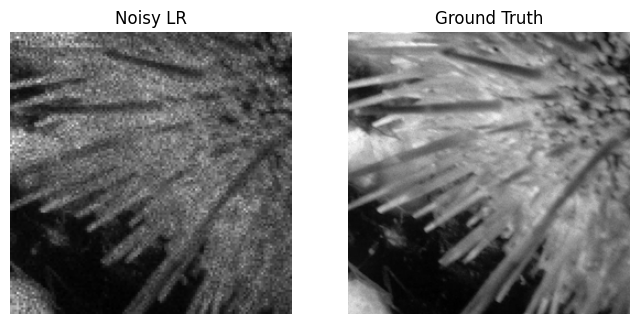

File: 000001.npy
LR shape: (128, 128) dtype: float32
GT shape: (256, 256) dtype: float32


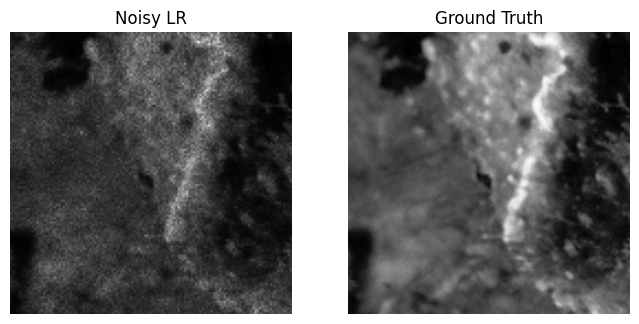

File: 000002.npy
LR shape: (128, 128) dtype: float32
GT shape: (256, 256) dtype: float32


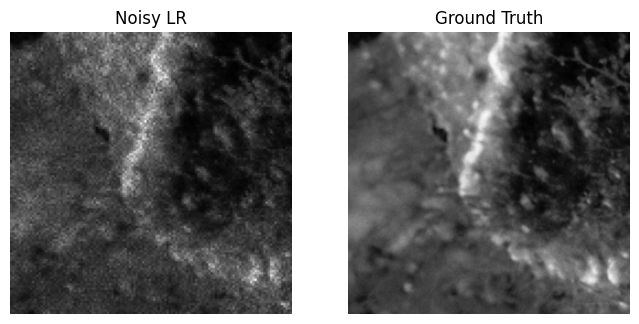

File: 000003.npy
LR shape: (128, 128) dtype: float32
GT shape: (256, 256) dtype: float32


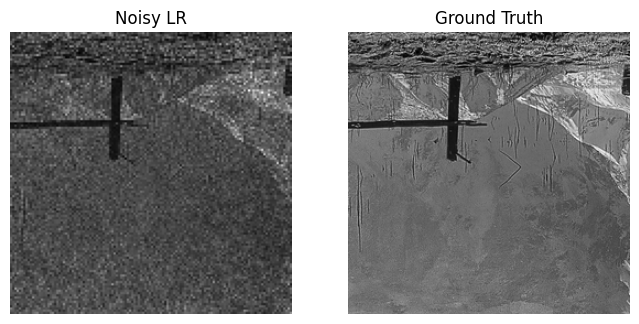

File: 000004.npy
LR shape: (128, 128) dtype: float32
GT shape: (256, 256) dtype: float32


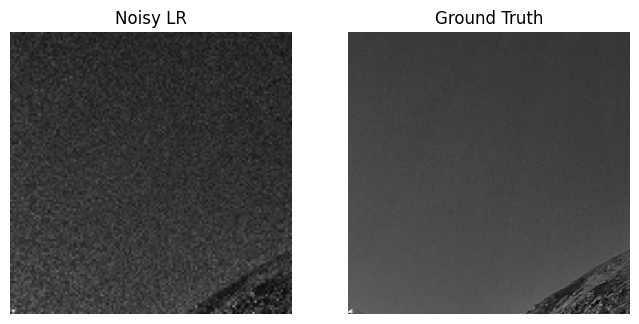

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

lr_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/train/NoisyLR"
gt_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/train/GT"

files = sorted(os.listdir(lr_dir))

print("Total samples:", len(files))

for i in range(5):

    file = files[i]

    lr_path = os.path.join(lr_dir, file)
    gt_path = os.path.join(gt_dir, file)

    lr = np.load(lr_path)
    gt = np.load(gt_path)

    print("File:", file)
    print("LR shape:", lr.shape, "dtype:", lr.dtype)
    print("GT shape:", gt.shape, "dtype:", gt.dtype)

    plt.figure(figsize=(8,4))

    plt.subplot(1,2,1)
    plt.title("Noisy LR")
    plt.imshow(lr, cmap="gray")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Ground Truth")
    plt.imshow(gt, cmap="gray")
    plt.axis("off")

    plt.show()

In [2]:
lr_shapes = set()
gt_shapes = set()

for file in files[:100]:

    lr = np.load(os.path.join(lr_dir, file))
    gt = np.load(os.path.join(gt_dir, file))

    lr_shapes.add(lr.shape)
    gt_shapes.add(gt.shape)

print("LR shapes:", lr_shapes)
print("GT shapes:", gt_shapes)

LR shapes: {(128, 128)}
GT shapes: {(256, 256)}


In [3]:
lr_shapes = set()
gt_shapes = set()

for file in files[:100]:

    lr = np.load(os.path.join(lr_dir, file))
    gt = np.load(os.path.join(gt_dir, file))

    lr_shapes.add(lr.shape)
    gt_shapes.add(gt.shape)

print("LR shapes:", lr_shapes)
print("GT shapes:", gt_shapes)


LR shapes: {(128, 128)}
GT shapes: {(256, 256)}


In [4]:
sample = files[0]

lr = np.load(os.path.join(lr_dir, sample))
gt = np.load(os.path.join(gt_dir, sample))

print("LR min/max:", lr.min(), lr.max())
print("GT min/max:", gt.min(), gt.max())

LR min/max: -0.013280108 1.4195464
GT min/max: 0.0 1.0


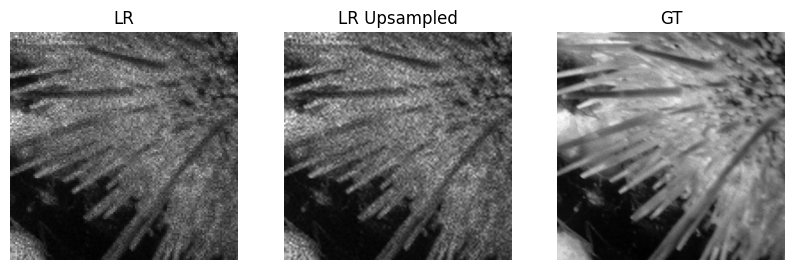

In [5]:
import cv2

lr_up = cv2.resize(lr, (256,256), interpolation=cv2.INTER_CUBIC)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("LR")
plt.imshow(lr, cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("LR Upsampled")
plt.imshow(lr_up, cmap="gray")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("GT")
plt.imshow(gt, cmap="gray")
plt.axis("off")

plt.show()

In [6]:
print("Example file:", files[0])

arr = np.load(os.path.join(lr_dir, files[0]))

print("shape:", arr.shape)
print("dtype:", arr.dtype)
print("min:", arr.min())
print("max:", arr.max())

Example file: 000000.npy
shape: (128, 128)
dtype: float32
min: -0.013280108
max: 1.4195464


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

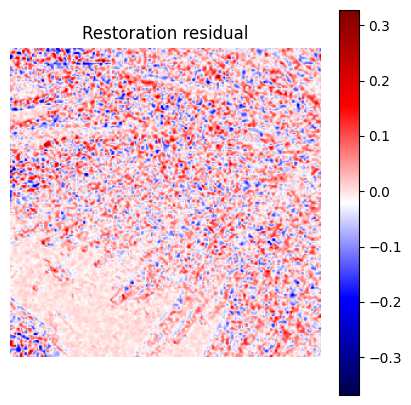

In [7]:
diff = gt - cv2.resize(lr, (256,256))

plt.figure(figsize=(5,5))
plt.title("Restoration residual")
plt.imshow(diff, cmap="seismic")
plt.colorbar()
plt.axis("off")

In [8]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
import torch.nn.functional as F

class KLADataset(Dataset):

    def __init__(self, lr_dir, gt_dir, files):

        self.lr_dir = lr_dir
        self.gt_dir = gt_dir
        self.files = files

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        name = self.files[idx]

        lr = np.load(os.path.join(self.lr_dir, name))
        gt = np.load(os.path.join(self.gt_dir, name))

        lr = torch.from_numpy(lr).float().unsqueeze(0)
        gt = torch.from_numpy(gt).float().unsqueeze(0)

        lr = torch.clamp(lr,0,1)
        gt = torch.clamp(gt,0,1)

        return lr, gt

In [9]:
from sklearn.model_selection import train_test_split

lr_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/train/NoisyLR"
gt_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/train/GT"

files = sorted(os.listdir(lr_dir))

train_files, val_files = train_test_split(
    files,
    test_size=0.1,
    random_state=42
)

In [10]:
from torch.utils.data import DataLoader

train_dataset = KLADataset(lr_dir, gt_dir, train_files)
val_dataset = KLADataset(lr_dir, gt_dir, val_files)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

In [11]:
import torch.nn as nn

class ResidualBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1)
        )

    def forward(self,x):
        return x + self.block(x)

In [12]:
class SimpleRestorationCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.entry = nn.Conv2d(1,64,3,padding=1)

        self.body = nn.Sequential(
            ResidualBlock(64),
            ResidualBlock(64),
            ResidualBlock(64),
            ResidualBlock(64)
        )

        self.upsample = nn.Sequential(
            nn.Conv2d(64,256,3,padding=1),
            nn.PixelShuffle(2),
            nn.ReLU()
        )

        self.exit = nn.Conv2d(64,1,3,padding=1)

    def forward(self,x):

        x = self.entry(x)
        x = self.body(x)
        x = self.upsample(x)
        x = self.exit(x)

        return torch.clamp(x,0,1)

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = SimpleRestorationCNN().to(device)

criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [14]:
best_val_loss = float("inf")
patience=5
patience_counter=0
save_path="working/best_model.pth"
os.makedirs(save_path,exist_ok=True)

In [15]:
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from pathlib import Path
train_losses = []
val_losses = []
ssim_history = []
psnr_history = []
epochs = 200

for epoch in range(epochs):
    # print(f"\nEpoch {epoch+1}/{epochs}")
    model.train()

    train_loss = 0

    for lr,gt in tqdm(train_loader,desc=f"Epoch {epoch+1}/{epochs}"):

        lr = lr.to(device)
        gt = gt.to(device)

        pred = model(lr)

        loss = criterion(pred,gt)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    
    val_loss = 0
    ssim_scores = []
    psnr_scores = []
    
    with torch.no_grad():
    
        for lr, gt in val_loader:
    
            lr = lr.to(device)
            gt = gt.to(device)
    
            pred = model(lr)
    
            loss = criterion(pred, gt)
    
            val_loss += loss.item()
    
            pred_np = pred.squeeze().cpu().numpy()
            gt_np = gt.squeeze().cpu().numpy()
    
            pred_np = np.clip(pred_np, 0, 1)
            gt_np = np.clip(gt_np, 0, 1)
    
            s = ssim(gt_np, pred_np, data_range=1)
            p = psnr(gt_np, pred_np, data_range=1)
    
            ssim_scores.append(s)
            psnr_scores.append(p)
    
    val_loss /= len(val_loader)
    
    mean_ssim = np.mean(ssim_scores)
    mean_psnr = np.mean(psnr_scores)
    
    val_losses.append(val_loss)
    ssim_history.append(mean_ssim)
    psnr_history.append(mean_psnr)
    
    print(f"Epoch {epoch+1}")
    print("Train Loss:", train_loss)
    print("Val Loss:", val_loss)
    print("Val SSIM:", mean_ssim)
    print("Val PSNR:", mean_psnr)

    if val_loss<best_val_loss:
        best_val_loss=val_loss
        best_model_ssim = mean_ssim  # The SSIM of the saved weights
        best_model_psnr = mean_psnr  # The PSNR of the saved weights
        patience_counter=0
        checkpoint_dir = Path("/kaggle/working")
        checkpoint_dir.mkdir(parents=True, exist_ok=True)

        save_path = checkpoint_dir / "best_model.pth"
        if save_path.exists() and save_path.is_dir():
            save_path = checkpoint_dir / "best_model_file.pth"

        tmp_path = checkpoint_dir / (save_path.name + ".tmp")
        torch.save(model.state_dict(), str(tmp_path))
        tmp_path.replace(save_path)

        print(f"Best model saved at: {save_path}")

    else:

        patience_counter += 1
        print("Early stop counter:", patience_counter)

    # ---------------- EARLY STOPPING ----------------

    if patience_counter >= patience:

        print("\nEarly stopping triggered")
        break

# Outside the training loop:
print("\n--- Training Complete ---")
print(f"Best Checkpoint Val Loss: {best_val_loss:.6f}")
print(f"Best Checkpoint SSIM: {best_model_ssim:.4f}")
print(f"Best Checkpoint PSNR: {best_model_psnr:.2f}")

Epoch 1/200: 100%|██████████| 135/135 [00:28<00:00,  4.80it/s]


Epoch 1
Train Loss: 0.057608380223865864
Val Loss: 0.04096293126543363
Val SSIM: 0.9651383114776547
Val PSNR: 23.993805817763928
Best model saved at: /kaggle/working/best_model.pth


Epoch 2/200: 100%|██████████| 135/135 [00:26<00:00,  5.16it/s]


Epoch 2
Train Loss: 0.03845940646198061
Val Loss: 0.037495957563320796
Val SSIM: 0.9692516371606191
Val PSNR: 24.658785936040015
Best model saved at: /kaggle/working/best_model.pth


Epoch 3/200: 100%|██████████| 135/135 [00:26<00:00,  5.09it/s]


...

Epoch 44
Train Loss: 0.033428222023778494
Val Loss: 0.03367580560346444
Val SSIM: 0.9740858786403911
Val PSNR: 25.373104580696545
Early stop counter: 3


Epoch 45/200: 100%|██████████| 135/135 [00:27<00:00,  4.90it/s]


Epoch 45
Train Loss: 0.03339291383270864
Val Loss: 0.03368893451988697
Val SSIM: 0.9740481096596082
Val PSNR: 25.379673348694052
Early stop counter: 4


Epoch 46/200: 100%|██████████| 135/135 [00:27<00:00,  4.91it/s]


Epoch 46
Train Loss: 0.033197660150903245
Val Loss: 0.033616757641235985
Val SSIM: 0.9740948648059462
Val PSNR: 25.38360539675261
Early stop counter: 5

Early stopping triggered

--- Training Complete ---
Best Checkpoint Val Loss: 0.033537
Best Checkpoint SSIM: 0.9738
Best Checkpoint PSNR: 25.38


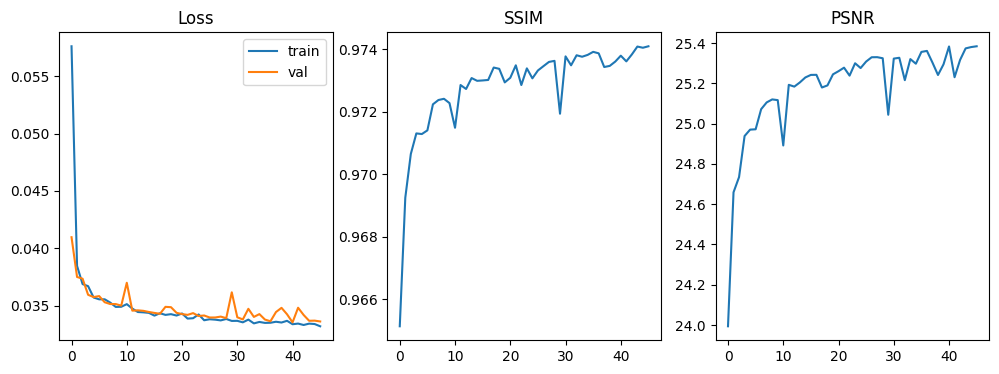

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(train_losses,label="train")
plt.plot(val_losses,label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(ssim_history)
plt.title("SSIM")

plt.subplot(1,3,3)
plt.plot(psnr_history)
plt.title("PSNR")

plt.show()

In [17]:
best_ssim = max(ssim_history)
best_psnr = max(psnr_history)

print("Best SSIM:", best_ssim)
print("Best PSNR:", best_psnr)

Best SSIM: 0.9740948648059462
Best PSNR: 25.38360539675261


In [18]:
# save_dir = "/kaggle/working/models"
# os.makedirs(save_dir, exist_ok=True)

# torch.save(model.state_dict(),os.path.join(save_dir, f"model_epoch_{epoch+1}.pth"))

In [19]:
# #Loading the saved model as and when needed
# model = SimpleRestorationCNN().to(device)

model.load_state_dict(
    torch.load("/kaggle/working/best_model.pth", map_location=device)
)

# model.eval()

<All keys matched successfully>

In [20]:
test_dir = "/kaggle/input/competitions/ExeBit_kla_ai_hack/KLA AI - HACK/test/NoisyLR"
save_dir = "/kaggle/working/submission"

os.makedirs(save_dir, exist_ok=True)

files = sorted(os.listdir(test_dir))

model.eval()

with torch.no_grad():

    for file in files:

        path = os.path.join(test_dir, file)

        lr = np.load(path)

        lr = torch.from_numpy(lr).float().unsqueeze(0).unsqueeze(0)
        lr = torch.clamp(lr,0,1)

        lr = lr.to(device)

        pred = model(lr)

        pred = pred.squeeze().cpu().numpy()

        pred = np.clip(pred,0,1).astype(np.float32)

        save_name = file
        save_path = os.path.join(save_dir, save_name)

        np.save(save_path, pred)

In [21]:
sample = np.load("/kaggle/working/submission/000000.npy")

print(sample.shape)
print(sample.dtype)
print(sample.min(), sample.max())

(256, 256)
float32
0.002340775 0.97228456


In [22]:
import base64
import pandas as pd
from io import BytesIO

submission_dir = "/kaggle/working/submission"

rows = []

files = sorted([f for f in os.listdir(submission_dir) if f.endswith(".npy")])

for idx, file in enumerate(files, start=1):

    path = os.path.join(submission_dir, file)

    arr = np.load(path)

    buffer = BytesIO()
    np.save(buffer, arr)

    encoded = base64.b64encode(buffer.getvalue()).decode()

    rows.append({
        "id": idx,
        "npy_base64": encoded
    })

df = pd.DataFrame(rows)

df.to_csv("/kaggle/working/submission.csv", index=False)

print("Submission created with", len(df), "rows")

Submission created with 200 rows


In [23]:
import os

print(os.listdir("/kaggle/working"))
print(len(os.listdir("/kaggle/working/submission")))

['__notebook__.ipynb', 'working', 'submission.csv', 'submission', 'best_model.pth']
200


In [24]:
import os
import numpy as np
import base64
import pandas as pd
from io import BytesIO

submission_dir = "/kaggle/working/submission"
csv_path = "/kaggle/working/submission.csv"

rows = []

files = sorted([f for f in os.listdir(submission_dir) if f.endswith(".npy")])

for idx, file in enumerate(files, start=1):

    path = os.path.join(submission_dir, file)

    arr = np.load(path)

    buffer = BytesIO()
    np.save(buffer, arr)

    encoded = base64.b64encode(buffer.getvalue()).decode()

    rows.append({
        "id": idx,
        "npy_base64": encoded
    })

df = pd.DataFrame(rows)

df.to_csv(csv_path, index=False)

print("Submission created:", csv_path)
print("Total rows:", len(df))

Submission created: /kaggle/working/submission.csv
Total rows: 200


In [25]:
!pip install torchinfo

In [26]:
from torchinfo import summary

summary(
    model,
    input_size=(1,1,128,128),
    col_names=["input_size","output_size","num_params","kernel_size"],
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
SimpleRestorationCNN                     [1, 1, 128, 128]          [1, 1, 256, 256]          --                        --
├─Conv2d: 1-1                            [1, 1, 128, 128]          [1, 64, 128, 128]         640                       [3, 3]
├─Sequential: 1-2                        [1, 64, 128, 128]         [1, 64, 128, 128]         --                        --
│    └─ResidualBlock: 2-1                [1, 64, 128, 128]         [1, 64, 128, 128]         --                        --
│    │    └─Sequential: 3-1              [1, 64, 128, 128]         [1, 64, 128, 128]         73,856                    --
│    └─ResidualBlock: 2-2                [1, 64, 128, 128]         [1, 64, 128, 128]         --                        --
│    │    └─Sequential: 3-2              [1, 64, 128, 128]         [1, 64, 128, 128]         73,856                    --
│    └─Res

In [27]:
total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)

Total parameters: 444353


In [28]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 12.6 MB/s eta 0:00:00


In [29]:
import torch

model.eval()

dummy_input = torch.randn(1,1,128,128).to(device)

onnx_path = "/kaggle/working/model.onnx"

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=11,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch"},
        "output": {0: "batch"}
    }
)

print("Model exported to:", onnx_path)

/tmp/ipykernel_23/2891145500.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0315 08:04:54.793000 23 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `SimpleRestorationCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SimpleRestorationCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py"

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 1 of general pattern rewrite rules.
Model exported to: /kaggle/working/model.onnx


In [30]:
import onnx

model_onnx = onnx.load("/kaggle/working/model.onnx")
onnx.checker.check_model(model_onnx)

print("ONNX model valid")

ONNX model valid
